# Reproducibility Notebook for BUSI Breast Cancer Results Audit

This notebook is designed as a **GitHub-ready standalone artifact** for users who already have the required input files in the repository.

## Assumed repository structure
This notebook assumes the following files already exist:

- `data/inputs/paper_summary.csv`
- `data/inputs/classification_report.csv`
- `data/inputs/models.csv`
- `data/inputs/paper_summary.json`

## What this notebook does
Using those input files, the notebook:

1. loads the reported study results,
2. performs a consistency audit,
3. generates clean output tables,
4. generates reviewer- and user-friendly figures,
5. saves all outputs to **Google Drive**.

## Important methodological note
This notebook works in **results-audit mode**. It is useful for:

- reproducibility of reported results,
- consistency checking,
- generating clean figures and tables,
- packaging materials for a GitHub repository.

It **does not perform new training, cross-validation, or external validation** unless raw BUSI image data and a full training pipeline are later added.


## Section 1 — Mount Google Drive

This notebook is intended for **Google Colab**.  
All generated outputs are saved to **Google Drive** so they can later be reused, archived, or exported.


In [14]:
# ============================================
# 1. MOUNT GOOGLE DRIVE
# ============================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path

DRIVE_ROOT = Path('/content/drive/MyDrive')
if not DRIVE_ROOT.exists():
    raise RuntimeError("Google Drive is not mounted correctly. '/content/drive/MyDrive' was not found.")

print("Google Drive mounted successfully at:", DRIVE_ROOT)

Mounted at /content/drive
Google Drive mounted successfully at: /content/drive/MyDrive


## Section 2 — Configuration

This section defines:

- the repository root containing the input files,
- the Google Drive output folders,
- the subfolders used for exported tables, figures, and notes.

### Expected workflow
- The repository already contains the required files in `data/inputs/`.
- This notebook reads those files directly.
- Generated outputs are saved to Google Drive.


In [15]:
# ============================================
# 2. CONFIGURATION
# ============================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

MODE = "results_only"

# Repository root on Google Drive
REPO_ROOT = Path("/content/drive/MyDrive/BUSI_Reproducibility_Package")

if not REPO_ROOT.exists():
    raise FileNotFoundError(
        f"Repository root not found: {REPO_ROOT}\n"
        "Please verify that the BUSI_Reproducibility_Package folder exists in MyDrive."
    )

# Input files expected inside the repository
INPUT_DIR = REPO_ROOT / "data" / "inputs"

if not INPUT_DIR.exists():
    raise FileNotFoundError(
        f"Input directory not found: {INPUT_DIR}\n"
        "Expected folder: data/inputs inside the repository root."
    )

# Output folders saved to Google Drive
PROJECT_ROOT = REPO_ROOT
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"
FIG_DIR = PROJECT_ROOT / "figures"
TABLE_DIR = PROJECT_ROOT / "tables"
NOTE_DIR = PROJECT_ROOT / "notes"

for folder in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, NOTE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("MODE:", MODE)
print("REPO_ROOT:", REPO_ROOT)
print("INPUT_DIR:", INPUT_DIR)
print("Google Drive output folders:")
for folder in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, NOTE_DIR]:
    print(" -", folder)

MODE: results_only
REPO_ROOT: /content/drive/MyDrive/BUSI_Reproducibility_Package
INPUT_DIR: /content/drive/MyDrive/BUSI_Reproducibility_Package/data/inputs
Google Drive output folders:
 - /content/drive/MyDrive/BUSI_Reproducibility_Package/data/outputs
 - /content/drive/MyDrive/BUSI_Reproducibility_Package/figures
 - /content/drive/MyDrive/BUSI_Reproducibility_Package/tables
 - /content/drive/MyDrive/BUSI_Reproducibility_Package/notes


## Section 3 — Load the repository input files

This section loads the existing repository inputs.  
No input files are created in this notebook.


In [16]:
# ============================================
# 3. LOAD INPUT DATA FROM THE REPOSITORY
# ============================================

paper_summary_csv = INPUT_DIR / "paper_summary.csv"
classification_report_csv = INPUT_DIR / "classification_report.csv"
models_csv = INPUT_DIR / "models.csv"
paper_summary_json = INPUT_DIR / "paper_summary.json"

required_files = [paper_summary_csv, classification_report_csv, models_csv, paper_summary_json]

missing = [fp for fp in required_files if not fp.exists()]
if missing:
    raise FileNotFoundError(
        "The following required input files were not found:\n" +
        "\n".join(str(fp) for fp in missing)
    )

paper_summary_df = pd.read_csv(paper_summary_csv)
classification_report_df = pd.read_csv(classification_report_csv)
models_df = pd.read_csv(models_csv)

with open(paper_summary_json, "r") as f:
    paper_summary = json.load(f)

display(paper_summary_df)
display(classification_report_df)
display(models_df)

print("All required input files were loaded successfully.")

,dataset,protocol,overall_test_accuracy,auc,weighted_precision,weighted_recall,weighted_f1,scope_note
0,BUSI,80:20 train-test split,0.885,0.985,0.86,0.86,0.86,Results-only audit mode; no new cross-validati...


,Class,Precision,Recall,F1-Score,Support
0,Benign,0.87,0.89,0.88,500.0
1,Malignant,0.80,0.86,0.83,256.0
2,Normal,0.87,0.84,0.86,161.0
3,Macro Avg,0.85,0.86,0.85,NaN
4,Weighted Avg,0.86,0.86,0.86,NaN


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Proposed Hybrid (NASNetMobile + EfficientNetB0),0.885,0.86,0.86,0.86,0.985
1,SVM,0.760,NaN,NaN,NaN,0.750
2,Decision Tree,0.710,NaN,NaN,NaN,0.650
3,Logistic Regression,0.720,NaN,NaN,NaN,0.700


All required input files were loaded successfully.


## Section 4 — Consistency audit

This section checks that the key metrics are internally consistent with the corrected manuscript.


In [17]:
# ============================================
# 4. CONSISTENCY AUDIT
# ============================================

print("Consistency audit")
print("- Dataset:", paper_summary["dataset"])
print("- Protocol:", paper_summary["protocol"])
print("- Accuracy:", paper_summary["overall_test_accuracy"])
print("- AUC:", paper_summary["auc"])
print("- Weighted Precision:", paper_summary["weighted_precision"])
print("- Weighted Recall:", paper_summary["weighted_recall"])
print("- Weighted F1:", paper_summary["weighted_f1"])

if paper_summary["overall_test_accuracy"] > 1:
    raise ValueError("Accuracy must be in decimal form, e.g., 0.885 rather than 88.5.")

if paper_summary["auc"] > 1 or paper_summary["auc"] < 0:
    raise ValueError("AUC must lie between 0 and 1.")

class_only = classification_report_df[classification_report_df["Class"].isin(["Benign", "Malignant", "Normal"])]
if class_only.empty:
    raise ValueError("Class-wise rows are missing from the classification report.")

print("\nAudit completed successfully.")

Consistency audit
- Dataset: BUSI
- Protocol: 80:20 train-test split
- Accuracy: 0.885
- AUC: 0.985
- Weighted Precision: 0.86
- Weighted Recall: 0.86
- Weighted F1: 0.86

Audit completed successfully.


## Section 5 — Generate publication-style tables

This section saves clean output tables for later reuse in the manuscript, supplementary materials, or GitHub workflow outputs.


In [18]:
# ============================================
# 5. GENERATE AND SAVE TABLE OUTPUTS
# ============================================

out_paper_summary_csv = TABLE_DIR / "table_paper_summary.csv"
out_classification_csv = TABLE_DIR / "table_classification_report.csv"
out_models_csv = TABLE_DIR / "table_model_comparison.csv"

paper_summary_df.to_csv(out_paper_summary_csv, index=False)
classification_report_df.to_csv(out_classification_csv, index=False)
models_df.to_csv(out_models_csv, index=False)

print("Saved output tables:")
for fp in [out_paper_summary_csv, out_classification_csv, out_models_csv]:
    print(" -", fp, "->", "FOUND" if fp.exists() else "MISSING")

Saved output tables:
 - /content/drive/MyDrive/BUSI_Reproducibility_Package/tables/table_paper_summary.csv -> FOUND
 - /content/drive/MyDrive/BUSI_Reproducibility_Package/tables/table_classification_report.csv -> FOUND
 - /content/drive/MyDrive/BUSI_Reproducibility_Package/tables/table_model_comparison.csv -> FOUND


## Section 6 — Generate figures

This section creates user-friendly figures from the reported paper results and saves them to Google Drive.


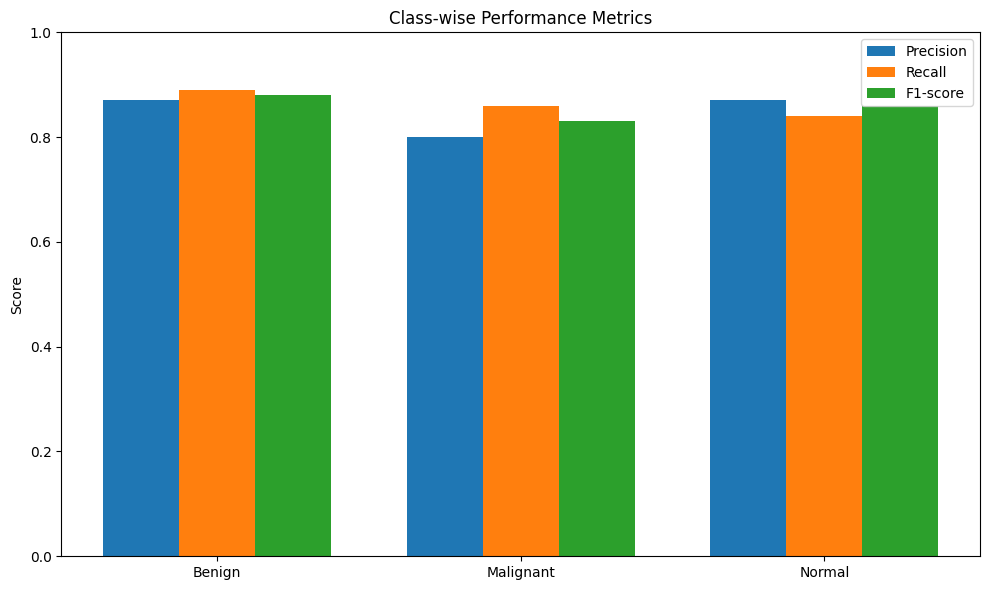

Saved: /content/drive/MyDrive/BUSI_Reproducibility_Package/figures/classwise_metrics.png -> FOUND


In [19]:
# ============================================
# 6. PLOT CLASS-WISE METRICS
# ============================================

class_df = classification_report_df[classification_report_df["Class"].isin(["Benign", "Malignant", "Normal"])].copy()

plt.figure(figsize=(10, 6))
x = np.arange(len(class_df))
w = 0.25

plt.bar(x - w, class_df["Precision"], width=w, label="Precision")
plt.bar(x, class_df["Recall"], width=w, label="Recall")
plt.bar(x + w, class_df["F1-Score"], width=w, label="F1-score")

plt.xticks(x, class_df["Class"])
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Class-wise Performance Metrics")
plt.legend()
plt.tight_layout()

class_metrics_fig = FIG_DIR / "classwise_metrics.png"
plt.savefig(class_metrics_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", class_metrics_fig, "->", "FOUND" if class_metrics_fig.exists() else "MISSING")

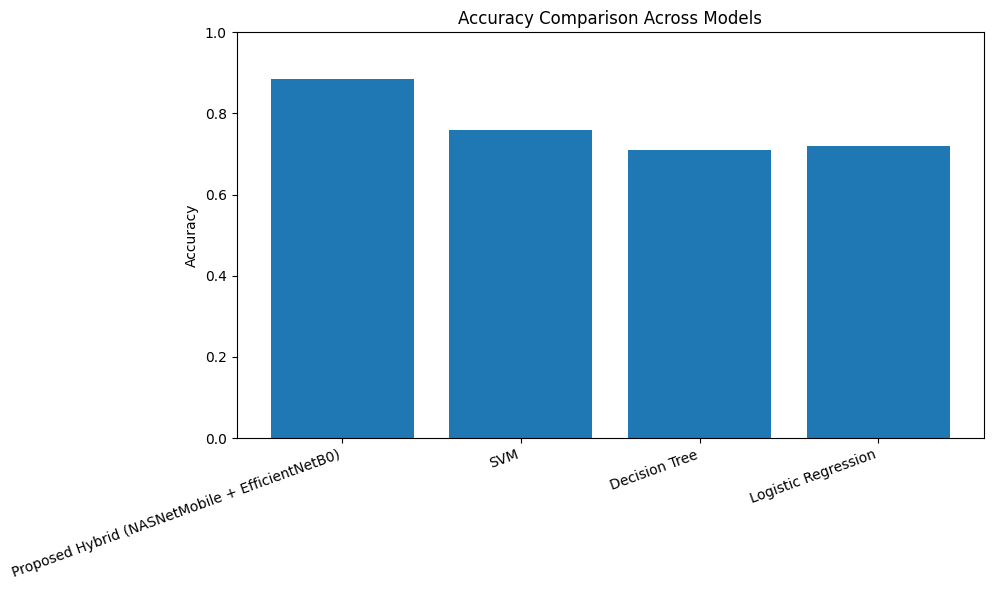

Saved: /content/drive/MyDrive/BUSI_Reproducibility_Package/figures/model_comparison.png -> FOUND


In [20]:
# ============================================
# 7. PLOT MODEL ACCURACY COMPARISON
# ============================================

plt.figure(figsize=(10, 6))
plt.bar(models_df["Model"], models_df["Accuracy"])
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison Across Models")
plt.tight_layout()

model_comparison_fig = FIG_DIR / "model_comparison.png"
plt.savefig(model_comparison_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", model_comparison_fig, "->", "FOUND" if model_comparison_fig.exists() else "MISSING")

## Section 7 — Create a human-readable outputs summary

This summary file is useful for:
- supplementary material,
- repository packaging,
- quick reviewer inspection.


In [21]:
# ============================================
# 8. WRITE SUMMARY NOTES
# ============================================

summary_txt = NOTE_DIR / "outputs_summary.txt"

with open(summary_txt, "w") as f:
    f.write("BUSI Reproducibility Package Summary\n")
    f.write("=" * 60 + "\n")
    f.write(f"Mode: {MODE}\n")
    f.write(f"Dataset: {paper_summary['dataset']}\n")
    f.write(f"Protocol: {paper_summary['protocol']}\n")
    f.write(f"Overall test accuracy: {paper_summary['overall_test_accuracy']:.4f}\n")
    f.write(f"AUC: {paper_summary['auc']:.4f}\n")
    f.write(f"Weighted precision: {paper_summary['weighted_precision']:.4f}\n")
    f.write(f"Weighted recall: {paper_summary['weighted_recall']:.4f}\n")
    f.write(f"Weighted F1: {paper_summary['weighted_f1']:.4f}\n")
    f.write("\nThis notebook is a results-audit artifact and does not claim new cross-validation or external validation.\n")

print("Saved summary note:", summary_txt, "->", "FOUND" if summary_txt.exists() else "MISSING")

Saved summary note: /content/drive/MyDrive/BUSI_Reproducibility_Package/notes/outputs_summary.txt -> FOUND


## Section 8 — Verify all saved artifacts

This final verification cell ensures that the expected output tables, figures, and notes are present on Google Drive.


In [22]:
# ============================================
# 9. VERIFY ALL ARTIFACTS
# ============================================

expected_files = [
    TABLE_DIR / "table_paper_summary.csv",
    TABLE_DIR / "table_classification_report.csv",
    TABLE_DIR / "table_model_comparison.csv",
    FIG_DIR / "classwise_metrics.png",
    FIG_DIR / "model_comparison.png",
    NOTE_DIR / "outputs_summary.txt",
]

print("Verification results:")
missing = []
for fp in expected_files:
    status = "FOUND" if fp.exists() else "MISSING"
    print(f" - {fp.name}: {status}")
    if status == "MISSING":
        missing.append(fp)

if missing:
    raise RuntimeError(f"Some expected files are missing: {missing}")
else:
    print("\nAll expected artifacts were successfully saved to Google Drive.")

Verification results:
 - table_paper_summary.csv: FOUND
 - table_classification_report.csv: FOUND
 - table_model_comparison.csv: FOUND
 - classwise_metrics.png: FOUND
 - model_comparison.png: FOUND
 - outputs_summary.txt: FOUND

All expected artifacts were successfully saved to Google Drive.


## Section 9 — Suggested next steps for GitHub

After running this notebook, the repository user will have:

- loaded the repository input files,
- generated clean output tables,
- generated output figures,
- exported all outputs to Google Drive.

A practical repository may contain:

- `notebooks/reproducibility_notebook.ipynb`
- `data/inputs/*.csv`
- `data/inputs/*.json`

and the user can optionally archive generated Drive outputs separately.
